In [2]:
## import neccessary libraries . 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import pingouin as pg


In [3]:
## load the data .

loan_data = pd.read_csv(r"C:\Users\HP\Desktop\data\JT_analytics\Analytics\loan_approval_df\loan_approval_dataset.csv")
## laod the data .
loan_data.head()

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected


In [4]:
## check the shape   
loan_data.shape

(4269, 13)

In [5]:
## checking the data types .
loan_data.dtypes

loan_id                       int64
 no_of_dependents             int64
 education                   object
 self_employed               object
 income_annum                 int64
 loan_amount                  int64
 loan_term                    int64
 cibil_score                  int64
 residential_assets_value     int64
 commercial_assets_value      int64
 luxury_assets_value          int64
 bank_asset_value             int64
 loan_status                 object
dtype: object

In [6]:
### checking for general information .
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [7]:
## checking for null values .
loan_data.isnull().sum()

loan_id                      0
 no_of_dependents            0
 education                   0
 self_employed               0
 income_annum                0
 loan_amount                 0
 loan_term                   0
 cibil_score                 0
 residential_assets_value    0
 commercial_assets_value     0
 luxury_assets_value         0
 bank_asset_value            0
 loan_status                 0
dtype: int64

In [8]:
## checking for null values in percentage .
loan_data.isnull().sum()/len(loan_data)*100


loan_id                      0.0
 no_of_dependents            0.0
 education                   0.0
 self_employed               0.0
 income_annum                0.0
 loan_amount                 0.0
 loan_term                   0.0
 cibil_score                 0.0
 residential_assets_value    0.0
 commercial_assets_value     0.0
 luxury_assets_value         0.0
 bank_asset_value            0.0
 loan_status                 0.0
dtype: float64

In [9]:
## strip white spaces from column names .
loan_data.columns = loan_data.columns.str.strip()
loan_data.columns


Index(['loan_id', 'no_of_dependents', 'education', 'self_employed',
       'income_annum', 'loan_amount', 'loan_term', 'cibil_score',
       'residential_assets_value', 'commercial_assets_value',
       'luxury_assets_value', 'bank_asset_value', 'loan_status'],
      dtype='object')

In [10]:
# Removing white spaces for string objects inside the dataframe
loan_data = loan_data.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

In [11]:
## check the data  
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   loan_id                   4269 non-null   int64 
 1   no_of_dependents          4269 non-null   int64 
 2   education                 4269 non-null   object
 3   self_employed             4269 non-null   object
 4   income_annum              4269 non-null   int64 
 5   loan_amount               4269 non-null   int64 
 6   loan_term                 4269 non-null   int64 
 7   cibil_score               4269 non-null   int64 
 8   residential_assets_value  4269 non-null   int64 
 9   commercial_assets_value   4269 non-null   int64 
 10  luxury_assets_value       4269 non-null   int64 
 11  bank_asset_value          4269 non-null   int64 
 12  loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


###     Summary-Statistics

In [12]:
## handling the negative values in residential_assets_value .
loan_data['residential_assets_value'] = loan_data['residential_assets_value'].abs()
## checking for descriptive statistics .
loan_data.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
loan_id,4269.0,2.135000e+03,1.232498e+03,1.0,1068.0,2135.0,3202.0,4269.0
no_of_dependents,4269.0,2.498712e+00,1.695910e+00,0.0,1.0,3.0,4.0,5.0
income_annum,4269.0,5.059124e+06,2.806840e+06,200000.0,2700000.0,5100000.0,7500000.0,9900000.0
loan_amount,4269.0,1.513345e+07,9.043363e+06,300000.0,7700000.0,14500000.0,21500000.0,39500000.0
loan_term,4269.0,1.090045e+01,5.709187e+00,2.0,6.0,10.0,16.0,20.0
cibil_score,4269.0,5.999361e+02,1.724304e+02,300.0,453.0,600.0,748.0,900.0
residential_assets_value,4269.0,7.473928e+06,6.502129e+06,0.0,2200000.0,5600000.0,11300000.0,29100000.0
commercial_assets_value,4269.0,4.973155e+06,4.388966e+06,0.0,1300000.0,3700000.0,7600000.0,19400000.0
luxury_assets_value,4269.0,1.512631e+07,9.103754e+06,300000.0,7500000.0,14600000.0,21700000.0,39200000.0
bank_asset_value,4269.0,4.976692e+06,3.250185e+06,0.0,2300000.0,4600000.0,7100000.0,14700000.0


In [13]:
### Compute Pearson correlation matrix
corr = loan_data.corr(method='pearson',numeric_only=True)

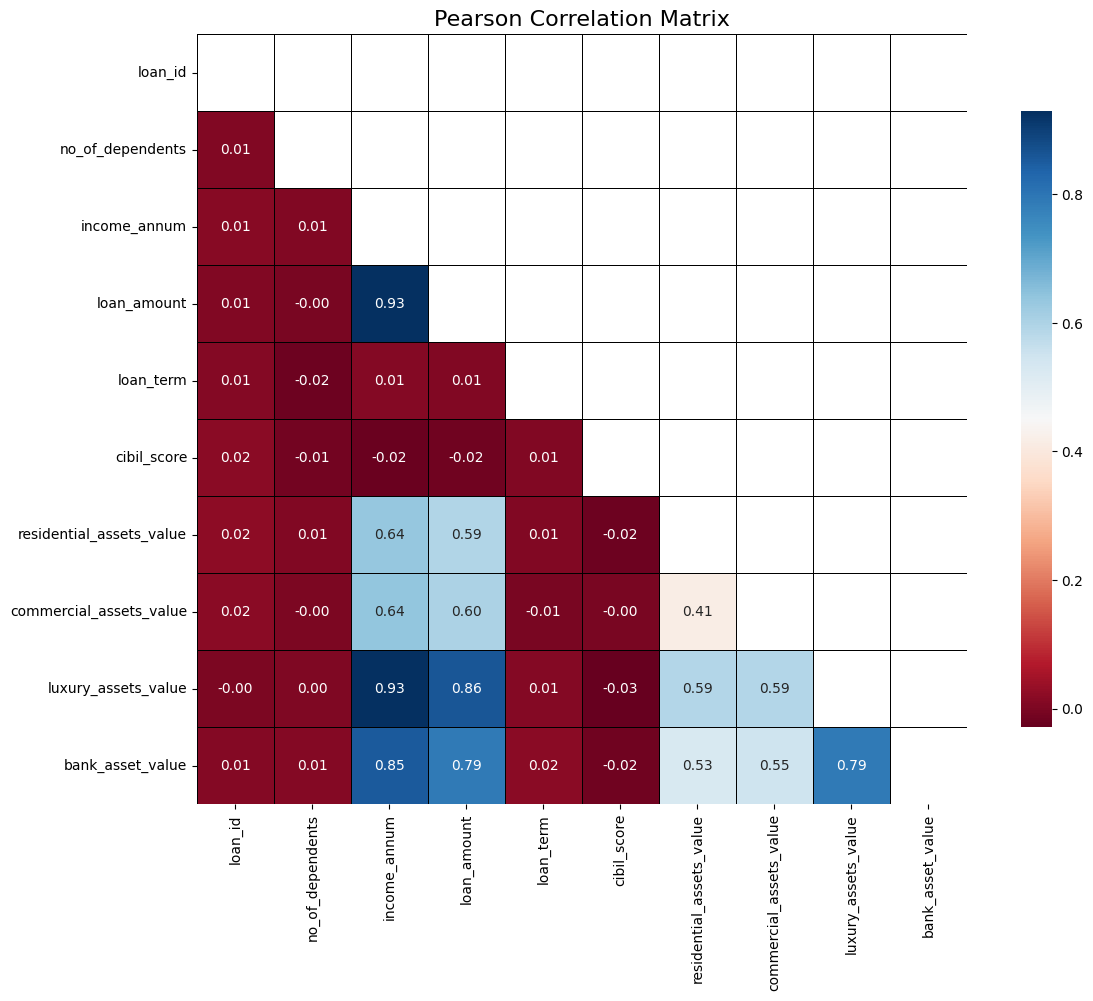

In [14]:
## heatmap with mask
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(14, 10))
sns.heatmap(corr, mask=mask, cmap='RdBu', annot=True, fmt='.2f', square=True, cbar_kws={"shrink": .8}, linewidths=0.5, linecolor='black')
plt.title('Pearson Correlation Matrix', fontsize=16)
plt.show()

###  Statiscal Analysis(T-Testst and Chi2)

In [15]:
## t-ttest performed to check the mean difference between loan status and income .
loan =loan_data['loan_amount']
income = loan_data['income_annum']
t_stat ,  p_value = stats.ttest_ind(loan ,income ,equal_var= True)
print('the t statistic is',t_stat)
print('the p_value is ',p_value)
if p_value < 0.05:
   print('Reject Null hpothesis')
else:
   print('fail to reject null hypothesis')


the t statistic is 69.51489699866843
the p_value is  0.0
Reject Null hpothesis


In [16]:
## comparing the mean of cibil score across Approved and not approved
pg.ttest(
    x=loan_data[loan_data['loan_status'] == 'Approved']['income_annum'],
    y=loan_data[loan_data['loan_status'] == 'Rejected']['income_annum'],
    paired=False,
    alternative='two-sided',
    correction=True,
    
)


,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,-0.997017,3454.006235,two-sided,0.318826,"[-260820.89, 84977.78]",0.031324,0.058,0.16813


In [17]:
## comparing the mean of cibil score across Approved and not approved
pg.ttest(
    x=loan_data[loan_data['loan_status'] == 'Approved']['commercial_assets_value'],
    y=loan_data[loan_data['loan_status'] == 'Rejected']['commercial_assets_value'],
    paired=False,
    alternative='two-sided',
    correction=True,
    
)

,T,dof,alternative,p-val,CI95%,cohen-d,BF10,power
T-test,0.538774,3404.905659,two-sided,0.590078,"[-196970.4, 346240.45]",0.017004,0.041,0.083832


In [18]:
## chi sqared between education and loan status .
stats.chi2_contingency(pd.crosstab(loan_data['education'], loan_data['loan_status']))


Chi2ContingencyResult(statistic=np.float64(0.08395754138250573), pvalue=np.float64(0.7720042291016309), dof=1, expected_freq=array([[1333.91051769,  810.08948231],
       [1322.08948231,  802.91051769]]))

In [19]:
## chi squared between self employed and loan status .
stats.chi2_contingency(pd.crosstab(loan_data['self_employed'], loan_data['loan_status']))

Chi2ContingencyResult(statistic=np.float64(0.0), pvalue=np.float64(1.0), dof=1, expected_freq=array([[1318.35652378,  800.64347622],
       [1337.64347622,  812.35652378]]))

In [20]:
## chi squared between no of dependents and loan status .
stats.chi2_contingency(pd.crosstab(loan_data['no_of_dependents'], loan_data['loan_status']))

Chi2ContingencyResult(statistic=np.float64(2.454183890937016), pvalue=np.float64(0.7833787033887646), dof=5, expected_freq=array([[442.97774654, 269.02225346],
       [433.6453502 , 263.3546498 ],
       [440.48910752, 267.51089248],
       [452.31014289, 274.68985711],
       [467.8641368 , 284.1358632 ],
       [418.71351605, 254.28648395]]))

### Logit Model.

In [21]:
## checking for the data   
loan_data.head(10)

,loan_id,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,1,2,Graduate,No,9600000,29900000,12,778,2400000,17600000,22700000,8000000,Approved
1,2,0,Not Graduate,Yes,4100000,12200000,8,417,2700000,2200000,8800000,3300000,Rejected
2,3,3,Graduate,No,9100000,29700000,20,506,7100000,4500000,33300000,12800000,Rejected
3,4,3,Graduate,No,8200000,30700000,8,467,18200000,3300000,23300000,7900000,Rejected
4,5,5,Not Graduate,Yes,9800000,24200000,20,382,12400000,8200000,29400000,5000000,Rejected
5,6,0,Graduate,Yes,4800000,13500000,10,319,6800000,8300000,13700000,5100000,Rejected
6,7,5,Graduate,No,8700000,33000000,4,678,22500000,14800000,29200000,4300000,Approved
7,8,2,Graduate,Yes,5700000,15000000,20,382,13200000,5700000,11800000,6000000,Rejected
8,9,0,Graduate,Yes,800000,2200000,20,782,1300000,800000,2800000,600000,Approved
9,10,5,Not Graduate,No,1100000,4300000,10,388,3200000,1400000,3300000,1600000,Rejected


In [22]:
loan_data['self_employed'].unique()

array(['No', 'Yes'], dtype=object)

In [23]:
## converting the loan status to binary
laon_status_categories = ['Rejected', 'Approved']
loan_data['loan_status'] = pd.Categorical(loan_data['loan_status'],categories=laon_status_categories)
loan_data['loan_status_binary'] = loan_data['loan_status'].cat.codes.astype('int')
## eduation 
education_categories = ['Not Graduate', 'Graduate']
loan_data['education'] = pd.Categorical(loan_data['education'], categories=education_categories, ordered=True)
loan_data['education_binary'] = loan_data['education'].cat.codes.astype('int') 
## self employes
self_employed_categories = ['No', 'Yes']
loan_data['self_employed'] = pd.Categorical(loan_data['self_employed'], categories=self_employed_categories, ordered=True)
loan_data['self_employed_binary'] = loan_data['self_employed'].cat.codes.astype('int')




In [24]:
# Convert categorical column to numeric if it's binary
loan_data['loan_status'] = loan_data['loan_status'].astype('category').cat.codes
## education
loan_data['education'] = loan_data['education'].astype('category').cat.codes
## self employed
loan_data['self_employed'] = loan_data['self_employed'].astype('category').cat.codes


In [25]:
## deleting the columns that are not needed .
loan_data.drop(columns=['loan_id'], inplace=True)

In [26]:
## display the data  
loan_data.head(10)

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status,loan_status_binary,education_binary,self_employed_binary
0,2,1,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,1,1,1,0
1,0,0,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,0,0,0,1
2,3,1,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,0,0,1,0
3,3,1,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,0,0,1,0
4,5,0,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,0,0,0,1
5,0,1,1,4800000,13500000,10,319,6800000,8300000,13700000,5100000,0,0,1,1
6,5,1,0,8700000,33000000,4,678,22500000,14800000,29200000,4300000,1,1,1,0
7,2,1,1,5700000,15000000,20,382,13200000,5700000,11800000,6000000,0,0,1,1
8,0,1,1,800000,2200000,20,782,1300000,800000,2800000,600000,1,1,1,1
9,5,0,0,1100000,4300000,10,388,3200000,1400000,3300000,1600000,0,0,0,0


### Standardizing the variables

In [27]:
### numerical columns .
numerical_columns = loan_data[['income_annum', 'loan_amount', 'cibil_score', 'residential_assets_value', 'commercial_assets_value', 'commercial_assets_value','bank_asset_value']]
## categorical columns .
categorical_coluumns = loan_data[['loan_status_binary', 'education_binary', 'self_employed_binary', 'no_of_dependents', 'loan_term']]


In [28]:
## standardizing the numerical columns .
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
numerical_columns_scaled = scaler.fit_transform(numerical_columns)
numerical_columns_scaled = pd.DataFrame(numerical_columns_scaled, columns=numerical_columns.columns)
## checking the data
numerical_columns_scaled.head(10)

,income_annum,loan_amount,cibil_score,residential_assets_value,commercial_assets_value,commercial_assets_value,bank_asset_value
0,1.617979,1.633052,1.032792,-0.780440,2.877289,2.877289,0.930304
1,-0.341750,-0.324414,-1.061051,-0.734296,-0.631921,-0.631921,-0.515936
2,1.439822,1.610933,-0.544840,-0.057515,-0.107818,-0.107818,2.407316
3,1.119139,1.721525,-0.771045,1.649818,-0.381263,-0.381263,0.899533
4,1.689242,1.002681,-1.264055,0.757698,0.735304,0.735304,0.007172
5,-0.092330,-0.180645,-1.629463,-0.103659,0.758091,0.758091,0.037943
6,1.297296,1.975885,0.452780,2.311217,2.239251,2.239251,-0.208226
7,0.228353,-0.014758,-1.264055,0.880749,0.165627,0.165627,0.314883
8,-1.517587,-1.430327,1.055993,-0.949635,-0.950940,-0.950940,-1.346756
9,-1.410692,-1.198085,-1.229255,-0.657389,-0.814218,-0.814218,-1.039045


In [29]:
## concatenate the scaled numerical columns with the categorical columns .
loan_data_scaled = pd.concat([numerical_columns_scaled, categorical_coluumns], axis=1)
## checking the data
loan_data_scaled.head(10)

,income_annum,loan_amount,cibil_score,residential_assets_value,commercial_assets_value,commercial_assets_value,bank_asset_value,loan_status_binary,education_binary,self_employed_binary,no_of_dependents,loan_term
0,1.617979,1.633052,1.032792,-0.780440,2.877289,2.877289,0.930304,1,1,0,2,12
1,-0.341750,-0.324414,-1.061051,-0.734296,-0.631921,-0.631921,-0.515936,0,0,1,0,8
2,1.439822,1.610933,-0.544840,-0.057515,-0.107818,-0.107818,2.407316,0,1,0,3,20
3,1.119139,1.721525,-0.771045,1.649818,-0.381263,-0.381263,0.899533,0,1,0,3,8
4,1.689242,1.002681,-1.264055,0.757698,0.735304,0.735304,0.007172,0,0,1,5,20
5,-0.092330,-0.180645,-1.629463,-0.103659,0.758091,0.758091,0.037943,0,1,1,0,10
6,1.297296,1.975885,0.452780,2.311217,2.239251,2.239251,-0.208226,1,1,0,5,4
7,0.228353,-0.014758,-1.264055,0.880749,0.165627,0.165627,0.314883,0,1,1,2,20
8,-1.517587,-1.430327,1.055993,-0.949635,-0.950940,-0.950940,-1.346756,1,1,1,0,20
9,-1.410692,-1.198085,-1.229255,-0.657389,-0.814218,-0.814218,-1.039045,0,0,0,5,10


In [30]:
## speify thee variables  
X = loan_data_scaled.drop(columns=['loan_status_binary'])
y = loan_data_scaled['loan_status_binary']


In [31]:
## addding the constant to the model .
X = sm.add_constant(X)

In [32]:
## fit Logit model
logit_model = sm.Logit(y, X).fit(disp=0)  

#### Logit Model

In [33]:
## summary of the model .
logit_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:     loan_status_binary   No. Observations:                 4269
Model:                          Logit   Df Residuals:                     4258
Method:                           MLE   Df Model:                           10
Date:                Mon, 07 Apr 2025   Pseudo R-squ.:                  0.6677
Time:                        15:23:12   Log-Likelihood:                -940.46
converged:                       True   LL-Null:                       -2830.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        3.3890      0.195     17.393      0.000       3.007       3.771
income_annum                -1.4453        nan        nan        nan         nan         nan
loan_amount                  1.3026      0.163      7.967      0.000       0.982       1.623
cibil_score                  4.2703      0.062     68.996      0.000       4.149       4.392
residential_assets_value     0.0166      0.077      0.215      0.829      -0.134       0.167
commercial_assets_value      0.0438   8.03e+15   5.45e-18      1.000   -1.57e+16    1.57e+16
commercial_assets_value      0.0438   8.03e+15   5.45e-18      1.000   -1.57e+16    1.57e+16
bank_asset_value             0.1622      0.104      1.561      0.118      -0.041       0.366
education_binary             0.1174      0.117      1.007      0.314      -0.111       0.346
self_employed_binary         0.0713      0.065      1.089      0.276      -0.057       0.200
no_of_dependents            -0.0196      0.035     -0.558      0.577      -0.088       0.049
loan_term                   -0.1504      0.010    -14.332      0.000      -0.171      -0.130
============================================================================================
"""

In [34]:
## significant factors that affect loan approval .
significant_factors = logit_model.pvalues[logit_model.pvalues < 0.05].index.tolist()
significant_factors


['const', 'loan_amount', 'cibil_score', 'loan_term']

#### Logit Marginal Effects

In [35]:
## the logit marginal effects .
logit_marginal_effects = logit_model.get_margeff()
logit_marginal_effects_summary = logit_marginal_effects.summary_frame()
logit_marginal_effects_summary

d:\tong_1\Lib\site-packages\statsmodels\discrete\discrete_margins.py:343: RuntimeWarning: invalid value encountered in sqrt
  return cov_me, np.sqrt(np.diag(cov_me))


,dy/dx,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
income_annum,-0.097633,NaN,NaN,NaN,NaN,NaN
loan_amount,0.087991,1.034700e-02,8.504035e+00,1.831118e-17,6.771153e-02,1.082710e-01
cibil_score,0.288463,7.775799e-04,3.709757e+02,0.000000e+00,2.869392e-01,2.899873e-01
residential_assets_value,0.001119,5.213718e-03,2.145769e-01,8.300972e-01,-9.099955e-03,1.133744e-02
commercial_assets_value,0.002956,5.427071e+14,5.447643e-18,1.000000e+00,-1.063686e+15,1.063686e+15
commercial_assets_value,0.002956,5.427071e+14,5.447641e-18,1.000000e+00,-1.063686e+15,1.063686e+15
bank_asset_value,0.010956,8.946460e-03,1.224608e+00,2.207229e-01,-6.578832e-03,2.849065e-02
education_binary,0.007931,7.874131e-03,1.007276e+00,3.138022e-01,-7.501591e-03,2.336443e-02
self_employed_binary,0.004816,4.526961e-03,1.063908e+00,2.873703e-01,-4.056409e-03,1.368895e-02
no_of_dependents,-0.001322,2.373284e-03,-5.568689e-01,5.776170e-01,-5.973160e-03,3.329944e-03


### Probit Model

In [36]:
##  The Probit Model
probit_model = sm.Probit(y, X).fit(disp=0)

In [37]:
## display the summary of the model .
probit_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                          Probit Regression Results                           
==============================================================================
Dep. Variable:     loan_status_binary   No. Observations:                 4269
Model:                         Probit   Df Residuals:                     4258
Method:                           MLE   Df Model:                           10
Date:                Mon, 07 Apr 2025   Pseudo R-squ.:                  0.6563
Time:                        15:23:12   Log-Likelihood:                -972.85
converged:                       True   LL-Null:                       -2830.3
Covariance Type:            nonrobust   LLR p-value:                     0.000
============================================================================================
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        1.8410        nan        nan        nan         nan         nan
income_annum                -0.7987      0.640     -1.248      0.212      -2.053       0.456
loan_amount                  0.6879      0.160      4.307      0.000       0.375       1.001
cibil_score                  2.1916        nan        nan        nan         nan         nan
residential_assets_value     0.0374      0.042      0.900      0.368      -0.044       0.119
commercial_assets_value      0.0321        nan        nan        nan         nan         nan
commercial_assets_value      0.0321        nan        nan        nan         nan         nan
bank_asset_value             0.1049        nan        nan        nan         nan         nan
education_binary             0.0364      0.064      0.570      0.569      -0.089       0.162
self_employed_binary         0.0224      0.066      0.338      0.735      -0.107       0.152
no_of_dependents            -0.0050        nan        nan        nan         nan         nan
loan_term                   -0.0844      0.006    -14.312      0.000      -0.096      -0.073
============================================================================================

Possibly complete quasi-separation: A fraction 0.13 of observations can be
perfectly predicted. This might indicate that there is complete
quasi-separation. In this case some parameters will not be identified.
"""

In [38]:
## display the p-values of the model .
probit_model.pvalues[probit_model.pvalues < 0.05].index.tolist()


['loan_amount', 'loan_term']

### Probit Model Marginal Effects

In [39]:
## marginal effects of the model .
probit_marginal_effects = probit_model.get_margeff()
probit_marginal_effects_summary = probit_marginal_effects.summary_frame()
## display the summary of the marginal effects .
probit_marginal_effects_summary

d:\tong_1\Lib\site-packages\statsmodels\discrete\discrete_margins.py:343: RuntimeWarning: invalid value encountered in sqrt
  return cov_me, np.sqrt(np.diag(cov_me))


,dy/dx,Std. Err.,z,Pr(>|z|),Conf. Int. Low,Cont. Int. Hi.
income_annum,-0.104804,0.087887,-1.192490,0.233069,-0.277059,0.067451
loan_amount,0.090256,0.021144,4.268711,0.000020,0.048815,0.131696
cibil_score,0.287560,0.002677,107.426153,0.000000,0.282313,0.292806
residential_assets_value,0.004913,0.005850,0.839857,0.400988,-0.006552,0.016378
commercial_assets_value,0.004211,NaN,NaN,NaN,NaN,NaN
commercial_assets_value,0.004211,NaN,NaN,NaN,NaN,NaN
bank_asset_value,0.013760,0.023401,0.588007,0.556527,-0.032106,0.059626
education_binary,0.004777,0.008376,0.570301,0.568474,-0.011640,0.021194
self_employed_binary,0.002941,0.008223,0.357683,0.720581,-0.013176,0.019058
no_of_dependents,-0.000654,NaN,NaN,NaN,NaN,NaN


### Performing the Logist Regression Model 

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve, accuracy_score


In [41]:
## perfrom the logitsic regression
X = loan_data_scaled.drop(columns=['loan_status_binary'])
y = loan_data_scaled['loan_status_binary']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
## fit the model .
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)

LogisticRegression()

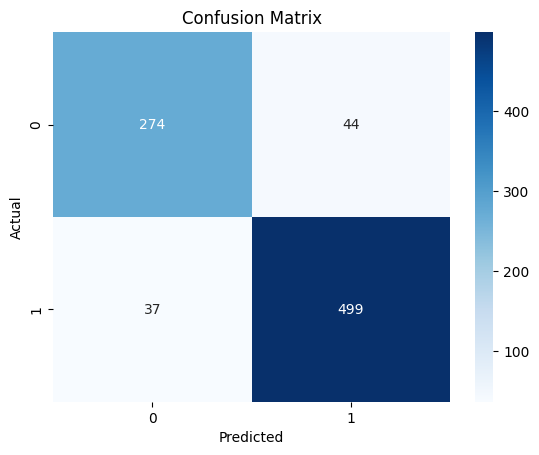

In [43]:
## predict the test data .
y_pred = log_reg.predict(X_test)
## predict the probabilities .
y_pred_proba = log_reg.predict_proba(X_test)[:, 1]
## display the confusion matrix .
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

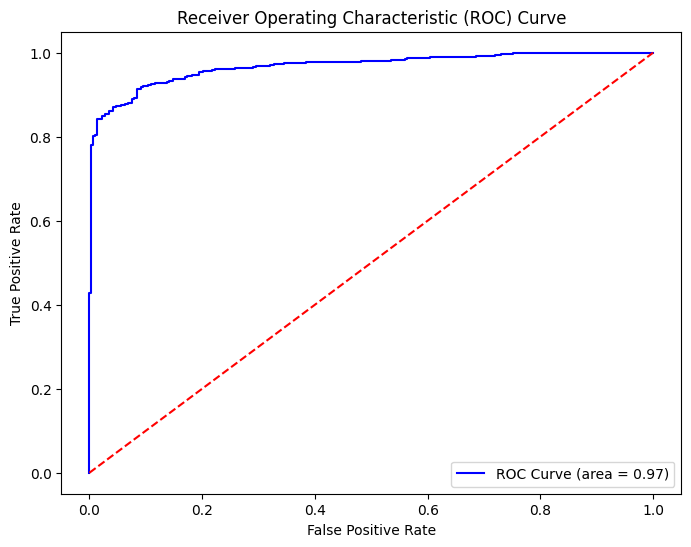

AUC score: 0.9674211489721206


In [44]:
## The ROC curve .
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label='ROC Curve (area = {:.2f})'.format(roc_auc_score(y_test, y_pred_proba)), color='blue')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.show()
## print the AUC score .
roc_auc = roc_auc_score(y_test, y_pred_proba)
print('AUC score:', roc_auc)

In [45]:
## the classifcation report .
print(classification_report(y_test, y_pred, target_names=['Rejected', 'Approved']))
## the accuracy score .
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)


              precision    recall  f1-score   support

    Rejected       0.88      0.86      0.87       318
    Approved       0.92      0.93      0.92       536

    accuracy                           0.91       854
   macro avg       0.90      0.90      0.90       854
weighted avg       0.90      0.91      0.90       854

Accuracy: 0.905152224824356


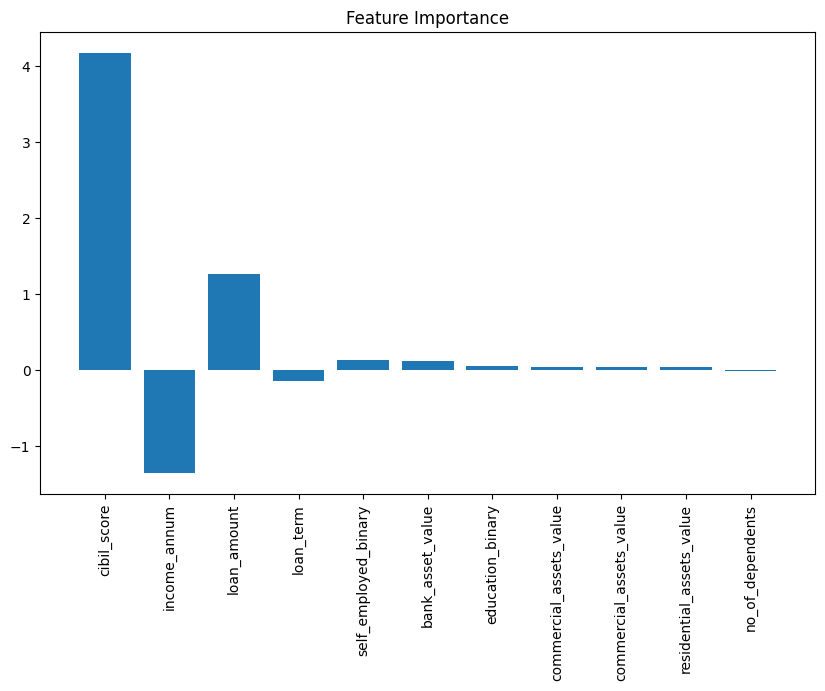

In [46]:
### Feature Importance using Logistic Regression
importances = log_reg.coef_[0]
feature_names = X.columns
indices = np.argsort(np.abs(importances))[::-1]
plt.figure(figsize=(10, 6))
plt.title("Feature Importance")
plt.bar(range(X.shape[1]), importances[indices], align="center")
plt.xticks(range(X.shape[1]), feature_names[indices], rotation=90)
plt.xlim([-1, X.shape[1]])
plt.show()

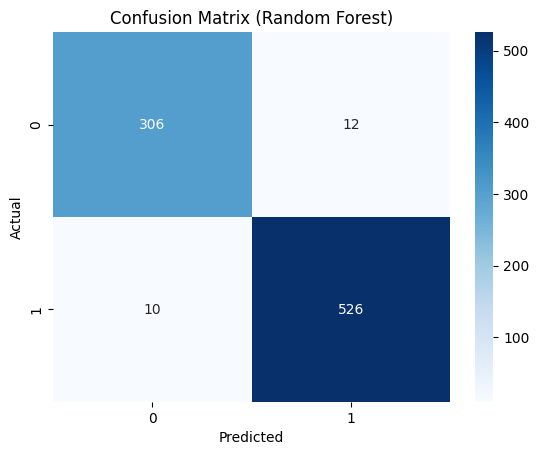

In [47]:
## randon Forest Model 
from sklearn.ensemble import RandomForestClassifier
## fit thee model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
## predict the test data .
y_pred_rf = rf_model.predict(X_test)
## predict the probabilities .
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]
## display the confusion matrix .
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Random Forest)')
plt.show()


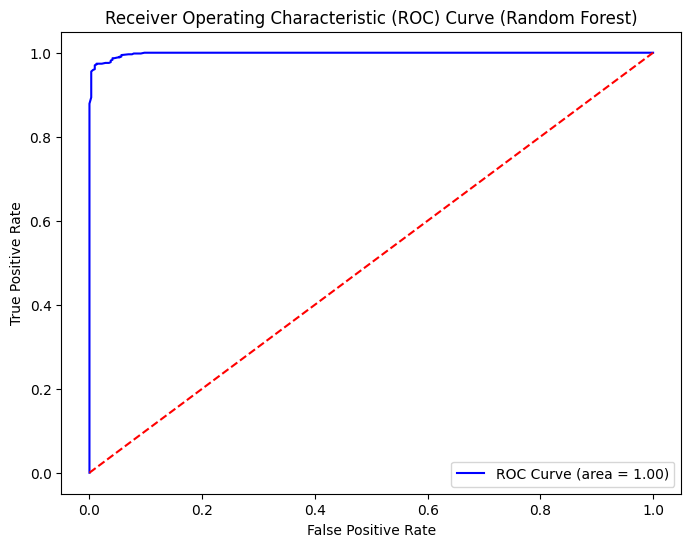

AUC score (Random Forest): 0.9983015347789356


In [48]:
## The ROC curve .
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_pred_proba_rf)
plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, label='ROC Curve (area = {:.2f})'.format(roc_auc_score(y_test, y_pred_proba_rf)), color='blue')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (Random Forest)')
plt.legend(loc='lower right')
plt.show()
## print the AUC score .
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print('AUC score (Random Forest):', roc_auc_rf)


In [49]:
## the classifcation report .
print(classification_report(y_test, y_pred_rf, target_names=['Rejected', 'Approved']))
## the accuracy score .
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print('Accuracy (Random Forest):', accuracy_rf)


              precision    recall  f1-score   support

    Rejected       0.97      0.96      0.97       318
    Approved       0.98      0.98      0.98       536

    accuracy                           0.97       854
   macro avg       0.97      0.97      0.97       854
weighted avg       0.97      0.97      0.97       854

Accuracy (Random Forest): 0.9742388758782201
